# Verification: mitochondrial MT1 cAMP signaling (Suofu et al., 2017)

Two checks are required for curation, and both are done here.

1. **Model specification.** `mitochondrial_mt1_camp_signaling_suofu2017.bngl` is run
   with BioNetGen 2.9.3 exactly as committed and checked against the committed
   reference output in `reference/`. The same three-phase protocol is then integrated
   independently in NumPy/SciPy from a **hand-written** 26-state ODE system, transcribed
   from the eight reaction types of Supplementary Data Table 1 in Suofu et al. (2017)
   rather than parsed from the generated `.net` file. This is the check that the rules,
   the compartment assignments and BioNetGen's compartmental volume scaling all do what
   the paper's reaction table says.

2. **Reported simulation data.** The curated model is compared with everything the paper
   reports for these two simulations: the four simulated curves of **Fig. 4J** (the
   authors' own fit of this model), and the averaged cAMP time courses of **Fig. 4H**
   (melatonin) and **Fig. 4I** (DAMGO) that both fits target. Both are digitized here;
   the extraction is written out below and archived in `reference/`.

The parameter values in the `.bngl` are *not* the paper's. Suofu et al. (2017) report
their fit only as log10 posterior histograms with an unstated unit convention
(Supplementary Data Fig. S7), so it cannot be read back into a runnable model. The values
were redetermined against Fig. 4H/4I with PyBioNetFit in
`pybnf-jobs/Suofu-2017/mito_camp/`. What is verified here is therefore: BioNetGen
implements the paper's reaction scheme correctly, and the resulting model reproduces the
paper's plotted dynamics.

In [1]:
import json
import os
import re
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

MODEL_DIR = Path.cwd()
REF_DIR = MODEL_DIR / "reference"
STEM = "mitochondrial_mt1_camp_signaling_suofu2017"
PNG_FILE = MODEL_DIR / "verify_suofu2017.png"
PAPER_PDF = MODEL_DIR / ".." / ".." / "dev" / "papers" / "Soufu2017" / "PNAS.pdf"


def bionetgen_command(model_name):
    env_bng2 = os.environ.get("BNG2_PL")
    if env_bng2 and Path(env_bng2).expanduser().is_file():
        return ["perl", str(Path(env_bng2).expanduser()), model_name]
    bngpath = os.environ.get("BNGPATH")
    if bngpath and (Path(bngpath).expanduser() / "BNG2.pl").is_file():
        return ["perl", str(Path(bngpath).expanduser() / "BNG2.pl"), model_name]
    for cand in (Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl",):
        if cand.is_file():
            return ["perl", str(cand), model_name]
    return [sys.executable, "-m", "bionetgen", "run", "-i", model_name]


def run_bngl(stem, workdir=None):
    """Run <stem>.bngl in a scratch directory and return that directory."""
    workdir = Path(workdir or tempfile.mkdtemp(prefix="suofu2017_"))
    shutil.copy(MODEL_DIR / f"{stem}.bngl", workdir / f"{stem}.bngl")
    res = subprocess.run(bionetgen_command(f"{stem}.bngl"), cwd=workdir,
                         capture_output=True, text=True)
    assert res.returncode == 0, (res.stderr or res.stdout)[-3000:]
    return workdir


def load_table(path):
    with open(path) as fh:
        header = fh.readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))


print("BioNetGen:", " ".join(bionetgen_command("model.bngl")[:2]))

BioNetGen: perl /Users/wish/Simulations/BioNetGen-2.9.3/BNG2.pl


## 1a. BioNetGen run and reference reproducibility

The committed file runs three protocols in one chain: a long unstimulated relaxation to
the basal steady state (`_equil`), then melatonin (`_ode`) and DAMGO (`_damgo`), each
restarted from that same basal state. Every output is compared with the committed
reference copy in `reference/`.

In [2]:
work = run_bngl(STEM)

net_txt = (work / f"{STEM}.net").read_text()
n_species = len(re.findall(r"^\s+\d+\s", net_txt.split("begin species")[1]
                           .split("end species")[0], re.M))
n_rxn = len(re.findall(r"^\s+\d+\s", net_txt.split("begin reactions")[1]
                       .split("end reactions")[0], re.M))
print(f"network: {n_species} species, {n_rxn} reactions "
      f"(Suofu et al. 2017 report 30 ODEs; see the model's #@note:)")

bng = {}
for tag in ("equil", "ode", "damgo"):
    hdr, dat = load_table(work / f"{STEM}_{tag}.gdat")
    bng[tag] = (hdr, dat)
    hr, dr = load_table(REF_DIR / f"{STEM}_{tag}.gdat")
    assert hdr == hr, tag
    scale = np.maximum(np.abs(dr).max(axis=0), 1e-30)
    err = float((np.abs(dat - dr) / scale).max())
    print(f"{tag:6s}  {dat.shape[0]:4d} rows  max |fresh - reference| / column max = {err:.2e}")

COLS = {name: i for i, name in enumerate(bng["ode"][0])}
t_eq, y_eq = bng["equil"][1][:, 0], bng["equil"][1]
print(f"\nbasal steady state after {t_eq[-1]:.0e} s:")
for obs in ("cAMP_CY", "cAMP_ML", "ATP_CY", "AMP_CY"):
    v = y_eq[-1, COLS[obs]]
    drift = abs(v / y_eq[-2, COLS[obs]] - 1)
    print(f"  {obs:8s} {v:14.6g}   relative drift over the last output step {drift:.1e}")
print(f"  cAMP_ML / (phi * cAMP_CY) = "
      f"{y_eq[-1, COLS['cAMP_ML']] / (0.011309733552923255 * y_eq[-1, COLS['cAMP_CY']]):.6f}"
      "   (1 = the two compartments hold equal cAMP concentration, as the paper assumes)")

network: 26 species, 30 reactions (Suofu et al. 2017 report 30 ODEs; see the model's #@note:)
equil    401 rows  max |fresh - reference| / column max = 0.00e+00
ode      601 rows  max |fresh - reference| / column max = 0.00e+00
damgo    601 rows  max |fresh - reference| / column max = 0.00e+00

basal steady state after 2e+05 s:
  cAMP_CY     7.60808e+06   relative drift over the last output step 0.0e+00
  cAMP_ML         86045.4   relative drift over the last output step 0.0e+00
  ATP_CY      1.00207e+09   relative drift over the last output step 0.0e+00
  AMP_CY          2284.18   relative drift over the last output step 0.0e+00
  cAMP_ML / (phi * cAMP_CY) = 1.000000   (1 = the two compartments hold equal cAMP concentration, as the paper assumes)


## 1b. Independent implementation of Supplementary Data Table 1

The right-hand side below is written directly from the paper's reaction table, not from
the generated network. Each aqueous compartment (cytosol `c`, mitochondrial lumen `m`)
carries ten states -- free ATP, cAMP and AMP; free adenylyl cyclase, its ATP complex and
its Gi\* complex; free phosphodiesterase and its cAMP complex; inactive Gi and active
Gi\* -- and each membrane adds its receptors and their Gi complexes, giving
14 + 12 = 26 states, matching the generated network.

Two modelling conventions are reproduced explicitly, and getting either wrong changes the
answer:

* **Compartmental scaling.** Every second-order term is divided by the volume of the
  adjacent aqueous compartment (`V_cy` for a PM/CY reaction, `V_ml` for OMM/ML), which is
  what BioNetGen's `unit_conversion` does for a surface--volume reaction.
* **Nucleotide permeation.** The efflux constant `kdiff` and the influx constant
  `kdiff * phi` are not equal, so the two compartments equilibrate at equal
  *concentration* rather than at equal *count*.

In [3]:
def read_parameters(path):
    """Evaluate the .bngl parameters block in file order."""
    txt = Path(path).read_text()
    body = txt.split("begin parameters")[1].split("end parameters")[0]
    env = {}
    for raw in body.splitlines():
        line = raw.split("#", 1)[0].strip()
        if not line:
            continue
        name, expr = line.split(None, 1)
        env[name] = eval(expr.replace("^", "**"), {"__builtins__": {}}, dict(env))
    return env


P = read_parameters(MODEL_DIR / f"{STEM}.bngl")
print(f"phi = {P['phi']:.10g}   V_cy = {P['V_cy']:g} um^3   V_ml = {P['V_ml']:.6g} um^3")
print(f"A_pm = {P['A_pm']:.6g} um^2   A_omm = {P['A_omm']:.6g} um^2   "
      f"MT1 areal density on the PM at R_ref = {P['R_ref'] / P['A_pm']:.0f} /um^2")

# state layout
CY = ["T_c", "C_c", "M_c", "A_c", "AT_c", "AG_c", "P_c", "PC_c", "G_c", "Gs_c",
      "R1_c", "R1G_c", "R2_c", "R2G_c"]
ML = ["T_m", "C_m", "M_m", "A_m", "AT_m", "AG_m", "P_m", "PC_m", "G_m", "Gs_m",
      "R1_m", "R1G_m"]
IDX = {s: i for i, s in enumerate(CY + ML)}


def rhs(t, y, mt1_on, or_on):
    d = np.zeros_like(y)
    k6_mt1 = P["k6"] * mt1_on
    k6_or = P["k6"] * or_on
    for side, V, k6r1, k6r2 in (("c", P["V_cy"], k6_mt1, k6_or),
                                ("m", P["V_ml"], k6_mt1, 0.0)):
        T, C, M = (y[IDX[f"{x}_{side}"]] for x in "TCM")
        A, AT, AG = y[IDX[f"A_{side}"]], y[IDX[f"AT_{side}"]], y[IDX[f"AG_{side}"]]
        Pf, PC = y[IDX[f"P_{side}"]], y[IDX[f"PC_{side}"]]
        G, Gs = y[IDX[f"G_{side}"]], y[IDX[f"Gs_{side}"]]
        R1, R1G = y[IDX[f"R1_{side}"]], y[IDX[f"R1G_{side}"]]
        R2 = y[IDX["R2_c"]] if side == "c" else 0.0
        R2G = y[IDX["R2G_c"]] if side == "c" else 0.0

        v1f = P["k1f"] * A * T / V          # 1. AC + ATP -> AC.ATP
        v1r = P["k1r"] * AT                 # 1. reverse
        v2 = P["k2"] * AT                   # 2. AC.ATP -> AC + cAMP
        v3f = P["k3f"] * Pf * C / V         # 3. PDE + cAMP -> PDE.cAMP
        v3r = P["k3r"] * PC                 # 3. reverse
        v4 = P["k4"] * PC                   # 4. PDE.cAMP -> PDE + AMP
        v5 = P["k5"] * M                    # 5. AMP -> ATP
        v6a = k6r1 * R1 * G / V             # 6. MT1 + Gi -> MT1.Gi
        v7a = P["k7"] * R1G                 # 7. MT1.Gi -> MT1 + Gi*
        v6b = k6r2 * R2 * G / V             # 6. OR + Gi -> OR.Gi
        v7b = P["k7"] * R2G                 # 7. OR.Gi -> OR + Gi*
        v8f = P["k8f"] * A * Gs / V         # 8. AC + Gi* -> AC.Gi*
        v8r = P["k8r"] * AG                 # 8. reverse

        d[IDX[f"T_{side}"]] += -v1f + v1r + v5
        d[IDX[f"C_{side}"]] += v2 - v3f + v3r
        d[IDX[f"M_{side}"]] += v4 - v5
        d[IDX[f"A_{side}"]] += -v1f + v1r + v2 - v8f + v8r
        d[IDX[f"AT_{side}"]] += v1f - v1r - v2
        d[IDX[f"AG_{side}"]] += v8f - v8r
        d[IDX[f"P_{side}"]] += -v3f + v3r + v4
        d[IDX[f"PC_{side}"]] += v3f - v3r - v4
        d[IDX[f"G_{side}"]] += -v6a - (v6b if side == "c" else 0.0)
        d[IDX[f"Gs_{side}"]] += v7a + (v7b if side == "c" else 0.0) - v8f + v8r
        d[IDX[f"R1_{side}"]] += -v6a + v7a
        d[IDX[f"R1G_{side}"]] += v6a - v7a
        if side == "c":
            d[IDX["R2_c"]] += -v6b + v7b
            d[IDX["R2G_c"]] += v6b - v7b

    # nucleotide permeation of the OMM (free nucleotide only)
    for x in "TCM":
        flux = P["kdiff"] * P["phi"] * y[IDX[f"{x}_c"]] - P["kdiff"] * y[IDX[f"{x}_m"]]
        d[IDX[f"{x}_c"]] -= flux
        d[IDX[f"{x}_m"]] += flux
    return d


def y0_seed():
    y = np.zeros(len(IDX))
    y[IDX["T_c"]], y[IDX["C_c"]] = P["ATP_CY_0"], P["cAMP_CY_0"]
    y[IDX["A_c"]], y[IDX["P_c"]], y[IDX["G_c"]] = P["AC_CY_0"], P["PDE_CY_0"], P["Gi_CY_0"]
    y[IDX["R1_c"]], y[IDX["R2_c"]] = P["MT1_PM_0"], P["OR_PM_0"]
    y[IDX["T_m"]], y[IDX["C_m"]] = P["ATP_ML_0"], P["cAMP_ML_0"]
    y[IDX["A_m"]], y[IDX["P_m"]], y[IDX["G_m"]] = P["AC_ML_0"], P["PDE_ML_0"], P["Gi_ML_0"]
    y[IDX["R1_m"]] = P["MT1_OMM_0"]
    return y


def integrate(y0, t_eval, mt1_on, or_on):
    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), y0, t_eval=t_eval, method="LSODA",
                    args=(mt1_on, or_on), rtol=1e-10, atol=1e-6)
    assert sol.success, sol.message
    return sol.y


T_EQUIL = bng["equil"][1][-1, 0]
eq = integrate(y0_seed(), bng["equil"][1][:, 0], 0.0, 0.0)
scipy_runs = {"equil": eq}
for tag, (mt1, ORf) in (("ode", (1.0, 0.0)), ("damgo", (0.0, 1.0))):
    scipy_runs[tag] = integrate(eq[:, -1].copy(), bng[tag][1][:, 0], mt1, ORf)

print(f"{'protocol':8s} {'observable':10s} {'max |rel err| BNG vs SciPy':>28s}")
worst = 0.0
for tag in ("equil", "ode", "damgo"):
    hdr, dat = bng[tag]
    for obs, key in (("cAMP_CY", "C_c"), ("cAMP_ML", "C_m"), ("ATP_CY", "T_c"),
                     ("ATP_ML", "T_m"), ("AMP_CY", "M_c"), ("GiA_CY", None),
                     ("GiA_ML", None), ("ACfree_PM", "A_c"), ("ACfree_OMM", "A_m")):
        if key is None:      # GiA_* is free Gi* plus receptor-bound and AC-bound Gi*
            side = "c" if obs.endswith("CY") else "m"
            sim = scipy_runs[tag][IDX[f"Gs_{side}"]] + scipy_runs[tag][IDX[f"AG_{side}"]]
        else:
            sim = scipy_runs[tag][IDX[key]]
        ref = dat[:, hdr.index(obs)]
        scale = max(abs(ref).max(), 1e-30)
        e = float((np.abs(sim - ref) / scale).max())
        worst = max(worst, e)
        print(f"{tag:8s} {obs:10s} {e:28.2e}")
print(f"\nworst disagreement over all protocols and observables: {worst:.2e}")
assert worst < 1e-5

phi = 0.01130973355   V_cy = 1000 um^3   V_ml = 11.3097 um^3
A_pm = 483.598 um^2   A_omm = 113.097 um^2   MT1 areal density on the PM at R_ref = 2068 /um^2
protocol observable   max |rel err| BNG vs SciPy
equil    cAMP_CY                        3.18e-08
equil    cAMP_ML                        3.11e-08
equil    ATP_CY                         3.19e-10
equil    ATP_ML                         3.11e-10
equil    AMP_CY                         3.78e-08
equil    GiA_CY                         0.00e+00
equil    GiA_ML                         0.00e+00
equil    ACfree_PM                      6.77e-12
equil    ACfree_OMM                     4.49e-11
ode      cAMP_CY                        4.39e-09
ode      cAMP_ML                        9.79e-09
ode      ATP_CY                         3.30e-11
ode      ATP_ML                         7.30e-11
ode      AMP_CY                         4.32e-09
ode      GiA_CY                         2.52e-12
ode      GiA_ML                         2.68e-09
ode      AC

## 2. Digitization of Fig. 4H, Fig. 4I and Fig. 4J

Page 5 of the article is rendered at 1200 dpi with `pdftoppm`, and each panel is
calibrated from its own plotted tick marks (found as short dark runs just outside the
axis lines). Two extractors are needed.

* **Markers (Fig. 4H, Fig. 4I -- the data).** The plotted means are filled disks of
  radius ~18 px that overlap both each other and the mono-exponential line drawn through
  them, so connected components merge several markers into one blob. Instead the colour
  mask is matched-filtered with a disk of radius 16 px and peaks are picked greedily with
  a 22 px exclusion radius, which separates them. Grey/pale error bars fall outside the
  colour masks and are not picked up.
* **Lines (Fig. 4J -- the authors' simulated curves).** Column-by-column run tracking
  from an anchor at the right-hand end of each curve, taking at each column the run
  closest to the previous centre. Two panel-specific complications are handled: the
  "Model MT1"/"Model uOR" titles are drawn *inside* the axes at y ~ 1.0 and are masked
  out, and each curve's black line is overdrawn by its own grey credible band at early
  times, so the black curves are tracked on the union of the black and grey masks (the
  band is thin and centred on the curve; the residual bias is below 0.02 in fraction
  units, and only for t < ~180 s).

If the article PDF is not present -- `dev/` is not redistributed with this repository --
the committed CSVs in `reference/` are loaded instead and the extraction below is skipped.

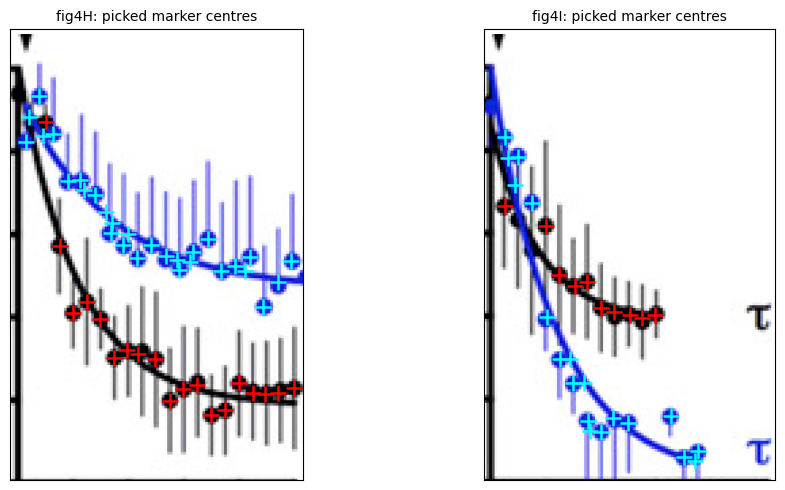

re-digitized from PNAS.pdf: 77 Fig. 4H/4I markers, 4 x 61 Fig. 4J samples
  max difference from the committed CSVs: 0 (Fig. 4H/4I), 4.97e-05 (Fig. 4J)

Fig. 4H/4I: 77 points; Fig. 4J: 61 samples per curve


In [4]:
DIG_HI = REF_DIR / "suofu2017_fig4HI_camp_timecourses_digitized.csv"
DIG_4J = REF_DIR / "suofu2017_fig4J_model_curves_digitized.csv"

PANELS = {
    "fig4H": dict(crop=(0.395, 0.50, 0.045, 0.27), interior=(8, 986, 702, 1330),
                  xt=([699.5, 819.5, 945.5, 1065.5, 1191.5, 1311.5], [0, 2, 4, 6, 8, 10]),
                  yt=([992.5, 809.5, 626.5, 443.5, 260.5, 77.5], [0, 20, 40, 60, 80, 100])),
    "fig4I": dict(crop=(0.395, 0.50, 0.24, 0.46), interior=(8, 986, 966, 1590),
                  xt=([960.5, 1083.5, 1203.5, 1329.5, 1449.5, 1569.5], [0, 2, 4, 6, 8, 10]),
                  yt=([989.5, 809.5, 623.5, 437.5, 257.5, 71.5], [0, 20, 40, 60, 80, 100])),
    "fig4J_MT1": dict(crop=(0.505, 0.63, 0.045, 0.27), interior=(372, 1266, 702, 1318),
                      exclude=[(25, 320, 0.94, 1.10)],
                      xt=([699.5, 1005.5, 1311.5], [0, 300, 600]),
                      yt=([1269.5, 1089.5, 903.5, 723.5, 537.5, 357.5],
                          [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])),
    "fig4J_uOR": dict(crop=(0.505, 0.63, 0.24, 0.46), interior=(370, 1266, 912, 1528),
                      exclude=[(25, 340, 0.94, 1.10)],
                      xt=([909.5, 1215.5, 1521.5], [0, 300, 600]),
                      yt=([1269.5, 1089.5, 903.5, 720.5, 537.5, 354.5],
                          [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])),
}


def _disk(rad):
    yy, xx = np.ogrid[-rad:rad + 1, -rad:rad + 1]
    return xx * xx + yy * yy <= rad * rad


class Panel:
    def __init__(self, page, name):
        from scipy import ndimage as ndi
        self.ndi = ndi
        s = PANELS[name]
        H, W, _ = page.shape
        fy0, fy1, fx0, fx1 = s["crop"]
        sub = page[int(H * fy0):int(H * fy1), int(W * fx0):int(W * fx1)]
        r, g, b = (sub[:, :, i].astype(int) for i in range(3))
        self.black = (r < 90) & (g < 90) & (b < 90)
        self.blue = (b - r > 60) & (b - g > 60)
        self.grey = (~self.black) & (~self.blue) & (r < 205) & \
                    (abs(r - b) < 45) & (abs(r - g) < 45)
        self.r0, self.r1, self.c0, self.c1 = s["interior"]
        self.interior = np.zeros(sub.shape[:2], bool)
        self.interior[self.r0:self.r1, self.c0:self.c1] = True
        self.fx = np.polyfit(np.array(s["xt"][0], float), np.array(s["xt"][1], float), 1)
        self.fy = np.polyfit(np.array(s["yt"][0], float), np.array(s["yt"][1], float), 1)
        for xa, xb, ya, yb in s.get("exclude", []):
            ra, rb = sorted((int(self.py(ya)), int(self.py(yb))))
            self.interior[ra:rb + 1, int(self.px(xa)):int(self.px(xb)) + 1] = False

    x = lambda self, p: np.polyval(self.fx, p)
    y = lambda self, p: np.polyval(self.fy, p)
    px = lambda self, v: (v - self.fx[1]) / self.fx[0]
    py = lambda self, v: (v - self.fy[1]) / self.fy[0]

    def markers(self, colour, rad=16, excl=22, frac=0.80):
        mask = (getattr(self, colour) & self.interior).astype(float)
        k = _disk(rad).astype(float)
        score = self.ndi.convolve(mask, k, mode="constant")
        pts = []
        while score.max() >= frac * k.sum():
            yy, xx = np.unravel_index(int(np.argmax(score)), score.shape)
            pts.append((self.x(xx), self.y(yy)))
            score[max(0, yy - excl):yy + excl + 1, max(0, xx - excl):xx + excl + 1] = 0.0
        return np.array(sorted(pts))

    def track(self, mask, x_anchor, y_anchor, max_thick=45, max_jump=20):
        mask = mask & self.interior
        out, prev = {}, self.py(y_anchor)
        for step in (+1, -1):
            p, c, miss = prev, int(round(self.px(x_anchor))), 0
            while self.c0 <= c < self.c1:
                ys = np.where(mask[:, c])[0]
                tol, best = max_jump * min(1 + miss, 4), None
                runs = np.split(ys, np.where(np.diff(ys) > 3)[0] + 1) if ys.size else []
                for run in runs:
                    if run.size > max_thick:
                        continue
                    cen = run.mean()
                    if abs(cen - p) <= tol and (best is None or abs(cen - p) < abs(best - p)):
                        best = cen
                if best is None and runs:      # occluded: nearest point of the nearest run
                    cand = [v for v in (np.clip(p, r.min(), r.max()) for r in runs)
                            if abs(v - p) <= tol]
                    best = min(cand, key=lambda v: abs(v - p)) if cand else None
                if best is None:
                    miss += 1
                else:
                    out[c], p, miss = best, best, 0
                c += step
        cols = np.array(sorted(out))
        return np.column_stack([self.x(cols), self.y(np.array([out[c] for c in cols]))])


def digitize_from_pdf(pdf, overlay=True):
    from PIL import Image
    Image.MAX_IMAGE_PIXELS = None
    with tempfile.TemporaryDirectory() as tmp:
        subprocess.run(["pdftoppm", "-f", "5", "-l", "5", "-r", "1200", "-png",
                        str(pdf), os.path.join(tmp, "p")], check=True)
        page = np.asarray(Image.open(os.path.join(tmp, "p-05.png")).convert("RGB"))

    if overlay:      # visual check that every pick sits on a real marker
        ov, oaxes = plt.subplots(1, 2, figsize=(11, 5))
        for oax, panel in zip(oaxes, ("fig4H", "fig4I")):
            s = PANELS[panel]
            fy0, fy1, fx0, fx1 = s["crop"]
            hh, ww, _ = page.shape
            oax.imshow(page[int(hh * fy0):int(hh * fy1), int(ww * fx0):int(ww * fx1)])
            pp = Panel(page, panel)
            for colour, cross in (("blue", "cyan"), ("black", "red")):
                mk = pp.markers(colour)
                oax.plot(pp.px(mk[:, 0]), pp.py(mk[:, 1]), "+", color=cross, ms=12, mew=1.8)
            oax.set_xlim(pp.c0 - 20, pp.c1)
            oax.set_ylim(pp.r1, pp.r0 - 20)
            oax.set_xticks([])
            oax.set_yticks([])
            oax.set_title(f"{panel}: picked marker centres", fontsize=10)
        ov.tight_layout()
        plt.show()

    rows = []
    for panel, fig, agonist in (("fig4H", "Fig. 4H", "melatonin"),
                                ("fig4I", "Fig. 4I", "DAMGO")):
        p = Panel(page, panel)
        for colour, comp in (("blue", "PM"), ("black", "OMM")):
            for tt, vv in p.markers(colour):
                rows.append((fig, agonist, comp, round(float(tt), 3), round(float(vv), 2)))

    ts = np.arange(0, 601, 10.0)
    cols = {}
    for panel, model, anchors in (("fig4J_MT1", "MT1", {"black": (595, 0.18),
                                                        "blue": (595, 0.44)}),
                                  ("fig4J_uOR", "uOR", {"black": (595, 0.30),
                                                        "blue": (595, 0.035)})):
        p = Panel(page, panel)
        for colour, comp in (("blue", "PM"), ("black", "OMM")):
            xa, ya = anchors[colour]
            mask = p.blue if colour == "blue" else (p.black | p.grey)
            cur = p.track(mask, xa, ya, max_thick=45 if colour == "blue" else 70)
            cur = np.vstack([[0.0, 1.0], cur[cur[:, 0] > 2]])
            cols[(model, comp)] = np.interp(ts, cur[:, 0], cur[:, 1])
    return rows, ts, cols


if PAPER_PDF.resolve().is_file() and shutil.which("pdftoppm"):
    rows, ts, cols = digitize_from_pdf(PAPER_PDF.resolve())
    fresh_hi = np.array([[r[3], r[4]] for r in rows])
    old_hi = np.genfromtxt(DIG_HI, delimiter=",", names=True)
    assert len(rows) == len(old_hi), (len(rows), len(old_hi))
    d = max(abs(fresh_hi[:, 0] - old_hi["time_min"]).max(),
            abs(fresh_hi[:, 1] - old_hi["camp_percent_of_max"]).max())
    old_4j = np.genfromtxt(DIG_4J, delimiter=",", names=True)
    d4 = max(abs(cols[(m, c)] - old_4j[f"{m}_{c}"]).max()
             for m, c in (("MT1", "PM"), ("MT1", "OMM"), ("uOR", "PM"), ("uOR", "OMM")))
    print(f"re-digitized from {PAPER_PDF.name}: {len(rows)} Fig. 4H/4I markers, "
          f"4 x {len(ts)} Fig. 4J samples")
    print(f"  max difference from the committed CSVs: {d:.3g} (Fig. 4H/4I), "
          f"{d4:.3g} (Fig. 4J)")
else:
    print(f"{PAPER_PDF} not available -- loading the committed digitization from "
          f"reference/ instead")

data_hi = np.genfromtxt(DIG_HI, delimiter=",", names=True,
                        dtype=None, encoding="utf-8")
data_4j = np.genfromtxt(DIG_4J, delimiter=",", names=True)
print(f"\nFig. 4H/4I: {len(data_hi)} points; Fig. 4J: {len(data_4j)} samples per curve")

## 3. Reported-simulation-data verification

Two comparisons, on the two things the paper reports.

**(a) Against the authors' own simulated curves, Fig. 4J.** This is the closest thing the
paper gives to a reference trajectory for this model. The curated model's cAMP is
expressed, as Fig. 4J does, as a fraction of the pre-agonist basal value, and compared
sample by sample over 0-600 s. Metrics are absolute differences in fraction units,
because three of the four curves decay below 0.3 where relative error divides by a small
number. Digitization alone is worth about +-0.02: the plotted lines are ~8 px half-width
at the 1200 dpi rendering against a y axis of 912 px per unit fraction (+-0.009), and the
grey credible band overdraws the black curves at early times.

This is a *comparison*, not a pass/fail check, and it does not come out at the
digitization level -- the two parameterizations differ by up to ~0.3 in fraction units
during the transient. They are two different fits of a sloppy 14-parameter model to the
same 77 points, and neither is the other's target: what (b) shows is that they score
comparably against the measurements, this one slightly better overall, with the
difference concentrated in one curve. The largest single disagreement is the DAMGO
luminal plateau, where Fig. 4J falls to 0.30 and this fit only to 0.50. That direction is
mechanistic rather than accidental: with no receptor on the OMM, luminal cAMP under DAMGO
falls only as fast as the cytosol drains it, so the same `kdiff` that lets the lumen reach
0.18 under melatonin (where the cytosol stays high and props it up) also keeps it near
0.5 under DAMGO. The data agree with this fit on that curve (RMSE 7.4 vs 8.7 pp) and with
the authors' on the melatonin curves.

**(b) Against the experimental data both fits target, Fig. 4H and Fig. 4I.** RMSE in
percentage points of the pre-agonist maximum, alongside the same statistic for the
authors' Fig. 4J curves, so the two fits are scored on the same 77 points.

In [5]:
FRAC = {"ode": ("cAMP_CY_frac", "cAMP_ML_frac"), "damgo": ("cAMP_CY_frac", "cAMP_ML_frac")}
PAPER_COL = {"ode": ("MT1_PM", "MT1_OMM"), "damgo": ("uOR_PM", "uOR_OMM")}
LABEL = {"ode": "melatonin (MT1: PM + OMM)", "damgo": "DAMGO (mu-OR: PM only)"}

print("(a) curated model vs. the authors' Fig. 4J curves, in fraction-of-basal units\n")
print(f"{'protocol':26s} {'curve':8s} {'max |diff|':>11s} {'median |diff|':>14s} "
      f"{'model @600s':>12s} {'Fig. 4J @600s':>14s}")
worst_4j = 0.0
for tag in ("ode", "damgo"):
    hdr, dat = bng[tag]
    for frac_obs, pcol, curve in zip(FRAC[tag], PAPER_COL[tag], ("PM/CY", "OMM/ML")):
        model = np.interp(data_4j["time_s"], dat[:, 0], dat[:, hdr.index(frac_obs)])
        ref = data_4j[pcol]
        diff = np.abs(model - ref)
        worst_4j = max(worst_4j, diff.max())
        print(f"{LABEL[tag]:26s} {curve:8s} {diff.max():11.3f} {np.median(diff):14.3f} "
              f"{model[-1]:12.3f} {ref[-1]:14.3f}")
print(f"\nworst difference from Fig. 4J over all four curves: {worst_4j:.3f} fraction units")

print("\n(b) both fits against the Fig. 4H / Fig. 4I data, in percentage points\n")
sel = lambda ag, comp: data_hi[(data_hi["agonist"] == ag) & (data_hi["compartment"] == comp)]
print(f"{'protocol':26s} {'curve':8s} {'n':>3s} {'RMSE this model':>16s} "
      f"{'RMSE Fig. 4J':>13s}")
tot = {"m": 0.0, "p": 0.0, "n": 0}
for tag, agonist in (("ode", "melatonin"), ("damgo", "DAMGO")):
    hdr, dat = bng[tag]
    for pct_obs, frac_obs, pcol, comp, curve in zip(
            ("camp_CY_pct", "camp_ML_pct"), FRAC[tag], PAPER_COL[tag],
            ("PM", "OMM"), ("PM/CY", "OMM/ML")):
        d = sel(agonist, comp)
        tsec = d["time_min"] * 60.0
        mine = np.interp(tsec, dat[:, 0], dat[:, hdr.index(pct_obs)])
        theirs = 100 * np.interp(tsec, data_4j["time_s"], data_4j[pcol])
        rm = np.sqrt(((mine - d["camp_percent_of_max"]) ** 2).mean())
        rp = np.sqrt(((theirs - d["camp_percent_of_max"]) ** 2).mean())
        tot["m"] += ((mine - d["camp_percent_of_max"]) ** 2).sum()
        tot["p"] += ((theirs - d["camp_percent_of_max"]) ** 2).sum()
        tot["n"] += len(d)
        print(f"{LABEL[tag]:26s} {curve:8s} {len(d):3d} {rm:16.2f} {rp:13.2f}")
print(f"{'ALL':26s} {'':8s} {tot['n']:3d} {np.sqrt(tot['m']/tot['n']):16.2f} "
      f"{np.sqrt(tot['p']/tot['n']):13.2f}")
print(f"\nSSE: this model {tot['m']:.1f}, authors' Fig. 4J curves {tot['p']:.1f} "
      f"(pybnf sos = SSE/2)")

(a) curated model vs. the authors' Fig. 4J curves, in fraction-of-basal units

protocol                   curve     max |diff|  median |diff|  model @600s  Fig. 4J @600s
melatonin (MT1: PM + OMM)  PM/CY          0.304          0.234        0.536          0.441
melatonin (MT1: PM + OMM)  OMM/ML         0.161          0.129        0.280          0.177
DAMGO (mu-OR: PM only)     PM/CY          0.141          0.066        0.009          0.034
DAMGO (mu-OR: PM only)     OMM/ML         0.216          0.175        0.496          0.299

worst difference from Fig. 4J over all four curves: 0.304 fraction units

(b) both fits against the Fig. 4H / Fig. 4I data, in percentage points

protocol                   curve      n  RMSE this model  RMSE Fig. 4J
melatonin (MT1: PM + OMM)  PM/CY     29             6.95          5.70
melatonin (MT1: PM + OMM)  OMM/ML    19             7.10          6.27
DAMGO (mu-OR: PM only)     PM/CY     19             6.42         10.14
DAMGO (mu-OR: PM only)     OMM/ML  

## 4. Figure

Rows: the two stimulations. Left column, the model-specification check (BioNetGen as
lines, the independent SciPy integration as open markers every 40th point). Right column,
the reported-data check (the curated model against the Fig. 4J curves of Suofu et al. and
against the Fig. 4H/4I measurements).

Saved verify_suofu2017.png


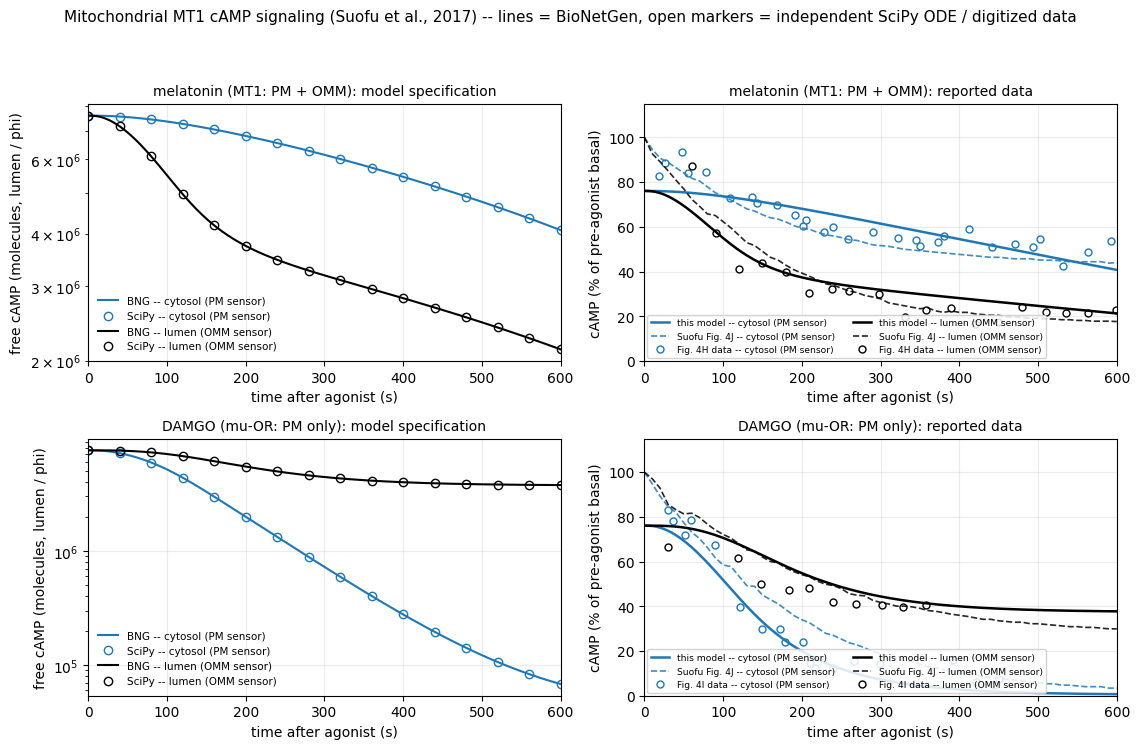

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.6))
CURVE = (("cAMP_CY", "C_c", "cAMP_CY_frac", "camp_CY_pct", "tab:blue",
          "cytosol (PM sensor)"),
         ("cAMP_ML", "C_m", "cAMP_ML_frac", "camp_ML_pct", "k", "lumen (OMM sensor)"))

for row, (tag, agonist) in enumerate((("ode", "melatonin"), ("damgo", "DAMGO"))):
    hdr, dat = bng[tag]
    t = dat[:, 0]

    ax = axes[row, 0]
    for obs, key, _, _, colour, lab in CURVE:
        ax.plot(t, dat[:, hdr.index(obs)] / (1 if obs == "cAMP_CY" else P["phi"]),
                color=colour, lw=1.5, label=f"BNG -- {lab}")
        ax.plot(t[::40], scipy_runs[tag][IDX[key]][::40] /
                (1 if obs == "cAMP_CY" else P["phi"]), "o", mfc="none", mec=colour, ms=6,
                label=f"SciPy -- {lab}")
    ax.set_yscale("log")
    ax.set_title(f"{LABEL[tag]}: model specification", fontsize=10)
    ax.set_ylabel("free cAMP (molecules, lumen / phi)")
    ax.legend(loc="lower left", frameon=False, fontsize=7.5)

    ax = axes[row, 1]
    for obs, _, frac_obs, pct_obs, colour, lab in CURVE:
        comp = "PM" if colour == "tab:blue" else "OMM"
        ax.plot(t, dat[:, hdr.index(pct_obs)], color=colour, lw=1.8,
                label=f"this model -- {lab}")
        ax.plot(data_4j["time_s"], 100 * data_4j[PAPER_COL[tag][0 if comp == "PM" else 1]],
                color=colour, lw=1.2, ls="--", alpha=0.85, label=f"Suofu Fig. 4J -- {lab}")
        d = sel(agonist, comp)
        ax.plot(d["time_min"] * 60, d["camp_percent_of_max"], "o", mfc="none", mec=colour,
                ms=5, label=f"Fig. 4{'H' if tag == 'ode' else 'I'} data -- {lab}")
    ax.set_ylim(0, 115)
    ax.set_title(f"{LABEL[tag]}: reported data", fontsize=10)
    ax.set_ylabel("cAMP (% of pre-agonist basal)")
    ax.legend(loc="lower left", fontsize=6.6, ncol=2, framealpha=0.85,
              borderaxespad=0.3)

for ax in axes.ravel():
    ax.set_xlim(0, 600)
    ax.set_xlabel("time after agonist (s)")
    ax.grid(alpha=0.25)
fig.suptitle("Mitochondrial MT1 cAMP signaling (Suofu et al., 2017) -- lines = BioNetGen, "
             "open markers = independent SciPy ODE / digitized data", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(PNG_FILE, dpi=150)
print(f"Saved {PNG_FILE.name}")

## Summary

* **Model specification.** BioNetGen's compartmental network agrees with an independent
  hand-written integration of Supplementary Data Table 1 to the tolerance printed in 1b.
  The basal state also satisfies the paper's design assumption exactly: luminal and
  cytosolic cAMP concentrations are equal to within the integration tolerance, which is
  the signature that the volume scaling and the concentration-matched initial quantities
  are both being applied as intended.
* **Reported data.** Scored on the 77 measured points of Fig. 4H and Fig. 4I, the curated
  model does slightly better than the authors' own Fig. 4J curves (see section 3b), and it
  reproduces the qualitative result the paper draws from them: under melatonin the
  mitochondrial lumen loses more cAMP than the cytosol, and under DAMGO the order
  reverses. The two parameterizations follow visibly different paths to that result, most
  of the difference sitting in the DAMGO luminal curve; section 3a says why.
* **What is not verified.** The individual rate constants: the paper gives no numeric
  values and no unit convention, so only the dynamics can be matched. Sections 1 and 3 of
  `pybnf-jobs/Suofu-2017/mito_camp/VALIDATION.md` record what the refit does and does not
  pin down.